In [1]:
from typing import Dict
import networkx as nx
import neuronav.utils as utils
import enum
import copy
import numpy as np
from gym import Env, spaces
from neuronav.envs.graph_templates import GraphTemplate, template_map
import torch


class GraphObservation(enum.Enum):
    onehot = "onehot"
    index = "index"
    images = "images"


class GraphEnv(Env):
    """
    Graph Environment.
    """

    def __init__(
        self,
        template: GraphTemplate = GraphTemplate.linear,
        obs_type: GraphObservation = GraphObservation.index,
        seed: int = None,
        use_noop: bool = False,
        torch_obs: bool = False,
    ):
        self.use_noop = use_noop
        self.rng = np.random.RandomState(seed)

        # Convert input strings to corresponding enums
        if isinstance(template, str):
            template = GraphTemplate(template)
        if isinstance(obs_type, str):
            obs_type = GraphObservation(obs_type)

        # Generate layout
        self.generate_layout(template)

        self.running = False
        self.obs_mode = obs_type
        self.torch_obs = torch_obs
        self.base_objects = {"rewards": {}}

        # Set observation space based on obs_mode
        if obs_type == GraphObservation.onehot:
            self.obs_space = spaces.Box(
                low=0, high=1, shape=(self.state_size,), dtype=np.int32
            )
        elif obs_type == GraphObservation.index:
            self.obs_space = spaces.Box(
                low=0, high=self.state_size - 1, shape=(1,), dtype=np.int32
            )
        elif obs_type == GraphObservation.images:
            self.obs_space = spaces.Box(0, 1, shape=(32, 32, 3))
            self.images = utils.cifar10()[0]

    def generate_layout(self, template: GraphTemplate):
        self.template_objects, self.edges = template_map[template]()
        self.agent_start_pos = 0
        action_size = 0
        for edge in self.edges:
            if len(edge) > action_size:
                action_size = len(edge)
        self.action_space = spaces.Discrete(action_size + self.use_noop)
        self.state_size = len(self.edges)

    @property
    def observation(self):
        if self.torch_obs:
            obs = self.get_observation()
            if self.obs_mode == GraphObservation.onehot:
                return torch.tensor(obs.copy(), dtype=torch.float32)
            elif self.obs_mode == GraphObservation.index:
                return torch.tensor(np.array([obs]).copy(), dtype=torch.int64)
            elif self.obs_mode == GraphObservation.images:
                img = np.moveaxis(obs, 2, 0)
                return torch.tensor(img.copy(), dtype=torch.float32)
        else:
            return self.get_observation()

    def get_observation(self):
        """
        Returns an observation corresponding to the current state.
        """
        if self.obs_mode == GraphObservation.onehot:
            return utils.onehot(self.agent_pos, self.state_size)
        elif self.obs_mode == GraphObservation.index:
            return self.agent_pos
        elif self.obs_mode == GraphObservation.images:
            return np.rot90(self.images[self.agent_pos], k=3)
        else:
            raise NotImplementedError

    def get_free_spot(self):
        return self.rng.randint(0, self.state_size)

    def reset(
        self,
        agent_pos: int = None,
        objects: Dict = None,
        random_start: bool = False,
        time_penalty: float = 0.0,
        stochasticity: float = 0.0,
    ):
        """
        Resets the environment to initial configuration.
        """
        self.running = True
        self.stochasticity = stochasticity
        self.time_penalty = time_penalty
        if agent_pos != None:
            self.agent_pos = agent_pos
        elif random_start:
            self.agent_pos = self.get_free_spot()
        else:
            self.agent_pos = self.agent_start_pos
        self.done = False
        if objects != None:
            use_objects = copy.deepcopy(self.base_objects)
            for key in objects.keys():
                if key in use_objects.keys():
                    use_objects[key] = objects[key]
            self.objects = use_objects
        else:
            self.objects = self.template_objects
        return self.observation

    def _get_node_color(self, idx):
        if idx == self.agent_pos:
            return "cornflowerblue"
        elif idx in self.objects["rewards"]:
            if self.objects["rewards"][idx] > 0:
                return [0, np.clip(self.objects["rewards"][idx], 0, 1), 0]
            elif self.objects["rewards"][idx] < 0:
                return [-np.clip(self.objects["rewards"][idx], -1, 0), 0, 0]
        return "silver"

    def render(self):
        """
        Renders the graph environment to a pyplot figure.
        """
        graph = nx.DiGraph()
        color_map = [self._get_node_color(idx) for idx in range(len(self.edges))]

        for idx, edge in enumerate(self.edges):
            graph.add_node(idx)
            for target in edge:
                if type(target) == tuple:
                    for subtarget in target[0]:
                        graph.add_edge(idx, subtarget)
                else:
                    graph.add_edge(idx, target)

        nx.draw(
            graph,
            with_labels=True,
            node_color=color_map,
            node_size=750,
            font_color="white",
            pos=nx.spring_layout(graph, k=3, pos=nx.kamada_kawai_layout(graph)),
        )

    def step(self, action: int):
        """
        Takes a step in the environment given an action.
        """
        if not self.running:
            print(
                f"Please call {self.__class__.__name__}.reset() before {self.__class__.__name__}.step()."
            )
            return None, None, None, None
        if self.done:
            print(
                f"Episode finished. Please reset the {self.__class__.__name__} environment."
            )
            return None, None, None, None

        # No-op action
        if self.use_noop and action == self.action_space.n - 1:
            reward = 0
        else:
            # Stochastic action selection
            if self.stochasticity > self.rng.rand():
                action = self.rng.randint(0, len(self.edges[self.agent_pos]))

            candidate_positions = self.edges[self.agent_pos][action]

            # Choose candidate position based on probability distribution
            if type(candidate_positions) == tuple:
                candidate_position = self.rng.choice(
                    candidate_positions[0], p=candidate_positions[1]
                )
            else:
                candidate_position = candidate_positions

            self.agent_pos = candidate_position

            reward = 0
            if self.agent_pos in self.objects["rewards"]:
                reward += self.objects["rewards"][self.agent_pos]
            reward -= self.time_penalty

            # Check if the episode is done
            if len(self.edges[self.agent_pos]) == 0:
                self.done = True

        return self.observation, reward, self.done, {}

In [13]:
class RewardMapGraphEnv(GraphEnv):

    def step(self, action: int):
        """
        Takes a step in the environment given an action.
        """
        if not self.running:
            print(
                f"Please call {self.__class__.__name__}.reset() before {self.__class__.__name__}.step()."
            )
            return None, None, None, None
        if self.done:
            print(
                f"Episode finished. Please reset the {self.__class__.__name__} environment."
            )
            return None, None, None, None

        # No-op action
        if self.use_noop and action == self.action_space.n - 1:
            reward = 0
        else:
            # Stochastic action selection
            if self.stochasticity > self.rng.rand():
                action = self.rng.randint(0, len(self.edges[self.agent_pos]))

            candidate_positions = self.edges[self.agent_pos][action]

            # Choose candidate position based on probability distribution
            if type(candidate_positions) == tuple:
                candidate_position = self.rng.choice(
                    candidate_positions[0], p=candidate_positions[1]
                )
            else:
                candidate_position = candidate_positions

            self.agent_pos = candidate_position

            reward = 0
            if self.agent_pos in self.objects["rewards"]:
                reward += self.objects["rewards"][self.agent_pos]()
            reward -= self.time_penalty

            # Check if the episode is done
            if len(self.edges[self.agent_pos]) == 0:
                self.done = True

        return self.observation, reward, self.done, {}

    def generate_layout(self, template: GraphTemplate):
        try:
            self.template_objects, self.edges, self.displays = template_map[template]()
        except:
            self.template_objects, self.edges = template_map[template]()
            

        self.agent_start_pos = 0
        action_size = 0
        for edge in self.edges:
            if len(edge) > action_size:
                action_size = len(edge)
        self.action_space = spaces.Discrete(action_size + self.use_noop)
        self.state_size = len(self.edges)

    def _get_node_color(self, idx):
            if idx == self.agent_pos:
                return "cornflowerblue"
            elif idx in self.objects["rewards"]:
                if self.objects["rewards"][idx]() > 0:
                    return [0, np.clip(self.objects["rewards"][idx](), 0, 1), 0]
                elif self.objects["rewards"][idx]() < 0:
                    return [-np.clip(self.objects["rewards"][idx](), -1, 0), 0, 0]
            return "silver"


In [14]:
import enum
import numpy as np

class FixedReward:

    def __init__(self, reward):
        self.reward = reward

    def get_reward(self):
        return self.reward

    def __call__(self):
        return self.get_reward()


class GraphTemplate2(enum.Enum):
    two_step = "two_step"


def two_step():
    reward_locs = {3: FixedReward(1), 4: FixedReward(-1), 5: FixedReward(0.5), 6: FixedReward(0.5)}
    edges = [[1, 2], [3, 4], [5, 6], [], [], [], []]
    displays = {0: [],
                1: [],
                2: [],
                3: [],
                4: [],
                5: [],
                6: []
               }
    objects = {"rewards": reward_locs}
    return objects, edges, displays


template_map = {
    GraphTemplate2.two_step: two_step,
}

In [15]:
rmge = RewardMapGraphEnv(template=GraphTemplate2.two_step)

In [16]:
rmge.reset()

0

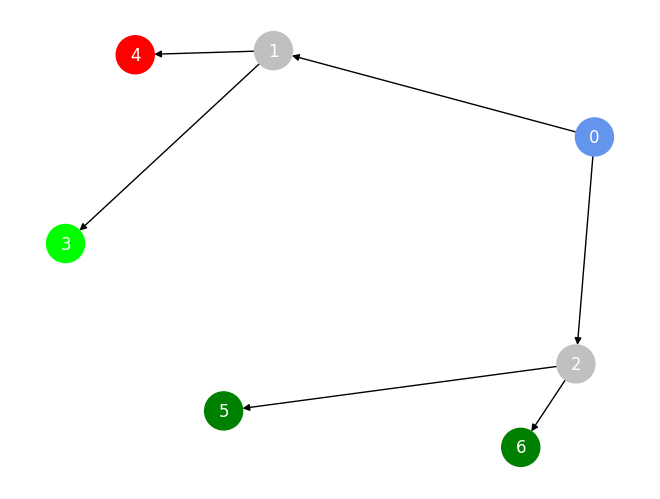

In [17]:
rmge.render()